# Generación de Indicadores Espaciotemporales del Sistema H2V

Este notebook genera indicadores del sistema de hidrógeno verde (H2V) en formato espaciotemporal compatible con los indicadores climáticos para su uso en modelos de aprendizaje profundo (autoencoder).

## Flujo:
1. Cargar RSDS bias-corrected (400 puntos) e Indicators SSP (760 puntos)
2. Interpolar RSDS a la grilla de 760 puntos (20 lat × 38 lon)
3. Calcular PV capacity factor por punto usando RSDS
4. Generar indicadores H2V espaciotemporales:
   - LCOH ($/MWh, $/kg)
   - Capacidades (PV, Electrolyzer, Storage)
   - Factor de capacidad (PV CF, Electrolyzer CF)
   - Producción H2 anual
   - Consumos (electricidad, agua)
5. Exportar a NetCDF y CSV en formato compatible con indicators_ssp

## Período: 2023-2100 (936 meses)
## Escenarios: SSP245, SSP370, SSP585
## Grilla espacial: 20 lat × 38 lon = 760 puntos (Valle de Aconcagua)

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"✅ Librerías cargadas - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías cargadas - 2025-10-18 23:34:53


## 1. Configuración de rutas y parámetros

In [2]:
# Rutas base
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
RSDS_DIR = BASE_DIR / 'data/cmip6/rsds/bias_corrected_qm'
INDICATORS_DIR = BASE_DIR / 'data/cmip6/indicators_ssp'
OUTPUT_DIR = BASE_DIR / 'data/cmip6/h2v_indicators_ssp'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Escenarios
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
MODELS = ['access', 'gfdl']  # Ambos modelos disponibles

# Parámetros del sistema H2V (basados en utils_calliope y literatura)
PARAMS = {
    'pv_efficiency': 0.20,           # Eficiencia PV (~20%)
    'electrolyzer_efficiency': 0.70, # Eficiencia electrolizador (70%)
    'h2_energy_content': 33.33,      # kWh/kg H2 (HHV)
    'water_consumption': 9.0,        # kg agua / kg H2
    
    # Costos (USD) - valores aproximados de referencia
    'pv_capex': 800,                 # USD/kW instalado
    'pv_opex_yearly': 20,            # USD/kW-año
    'electrolyzer_capex': 1200,      # USD/kW instalado
    'electrolyzer_opex_yearly': 40,  # USD/kW-año
    'storage_capex': 500,            # USD/kWh capacidad
    'water_cost': 1.5,               # USD/m3
    
    # Parámetros financieros
    'discount_rate': 0.08,           # 8% WACC
    'lifetime_years': 25,            # Vida útil del proyecto
    
    # Factores de dimensionamiento
    'pv_to_electrolyzer_ratio': 1.3, # Sobredimensionamiento PV
    'storage_hours': 4,              # Horas de almacenamiento H2
}

print(f"✅ Configuración cargada")
print(f"   Escenarios: {', '.join(SCENARIOS)}")
print(f"   Modelos: {', '.join(MODELS)}")
print(f"   Output: {OUTPUT_DIR}")

✅ Configuración cargada
   Escenarios: ssp245, ssp370, ssp585
   Modelos: access, gfdl
   Output: /home/aninotna/magister/tesis/justh2_pipeline/data/cmip6/h2v_indicators_ssp


## 2. Función: Convertir RSDS → PV Capacity Factor

Convierte la radiación solar de superficie (RSDS en W/m²) a factor de capacidad fotovoltaico.

**Modelo simplificado:**
$$
CF_{PV} = \frac{RSDS \times \eta_{PV} \times PR}{1000}
$$

Donde:
- $RSDS$: Radiación solar (W/m²)
- $\eta_{PV}$: Eficiencia del panel (~20%)
- $PR$: Performance Ratio (~0.85, pérdidas del sistema)
- $1000$: Irradiancia estándar (W/m²)

In [3]:
def rsds_to_pv_cf(rsds_wm2, efficiency=0.20, performance_ratio=0.85):
    """
    Convierte RSDS (W/m²) a PV capacity factor.
    
    Args:
        rsds_wm2: Radiación solar (W/m²) - xarray DataArray
        efficiency: Eficiencia del panel PV (default: 0.20)
        performance_ratio: Performance ratio del sistema (default: 0.85)
    
    Returns:
        pv_cf: Capacity factor (0-1) - xarray DataArray
    """
    # Irradiancia estándar (STC)
    G_stc = 1000  # W/m²
    
    # Calcular CF
    pv_cf = (rsds_wm2 * efficiency * performance_ratio) / G_stc
    
    # Limitar entre 0 y 1
    pv_cf = pv_cf.clip(0, 1)
    
    return pv_cf

print("✅ Función rsds_to_pv_cf definida")

✅ Función rsds_to_pv_cf definida


## 3. Función: Calcular LCOH simplificado

Cálculo del Levelized Cost of Hydrogen usando el método de anualización de costos.

$$
LCOH = \frac{CAPEX_{anualizado} + OPEX_{anual}}{H_2\ producido\ [MWh/año]}
$$

In [4]:
def calculate_lcoh_simple(pv_cf_annual, demand_mwh_year, params):
    """
    Calcula LCOH simplificado punto por punto.
    
    Args:
        pv_cf_annual: Capacity factor PV promedio anual (0-1)
        demand_mwh_year: Demanda anual de H2 (MWh/año)
        params: Diccionario con parámetros del sistema
    
    Returns:
        dict con: LCOH_per_MWh, LCOH_per_kg, capacidades, producción, consumos
    """
    # Factor de anualización (CRF - Capital Recovery Factor)
    r = params['discount_rate']
    n = params['lifetime_years']
    crf = (r * (1 + r)**n) / ((1 + r)**n - 1)
    
    # Dimensionamiento: electrolizador basado en demanda pico
    # Asumimos operación ~4000 h/año efectivas
    hours_per_year = 8760
    electrolyzer_cf = 0.5  # CF típico de electrolizador con renovables
    
    # Capacidad del electrolizador (MW)
    electrolyzer_mw = demand_mwh_year / (hours_per_year * electrolyzer_cf)
    
    # Capacidad PV (sobredimensionada respecto al electrolizador)
    pv_mw = electrolyzer_mw * params['pv_to_electrolyzer_ratio']
    
    # Almacenamiento H2 (horas de producción)
    storage_mwh = electrolyzer_mw * params['storage_hours']
    
    # CAPEX anualizado
    capex_pv = pv_mw * params['pv_capex'] * 1000 * crf  # USD/año
    capex_electrolyzer = electrolyzer_mw * params['electrolyzer_capex'] * 1000 * crf
    capex_storage = storage_mwh * params['storage_capex'] * 1000 * crf
    capex_total_annual = capex_pv + capex_electrolyzer + capex_storage
    
    # OPEX anual
    opex_pv = pv_mw * params['pv_opex_yearly'] * 1000  # USD/año
    opex_electrolyzer = electrolyzer_mw * params['electrolyzer_opex_yearly'] * 1000
    
    # Consumo de agua (m3/año)
    h2_kg_year = (demand_mwh_year * 1000) / params['h2_energy_content']
    water_m3_year = (h2_kg_year * params['water_consumption']) / 1000
    opex_water = water_m3_year * params['water_cost']
    
    opex_total_annual = opex_pv + opex_electrolyzer + opex_water
    
    # Costo total anual
    total_cost_annual = capex_total_annual + opex_total_annual
    
    # LCOH
    lcoh_per_mwh = total_cost_annual / demand_mwh_year if demand_mwh_year > 0 else np.nan
    lcoh_per_kg = lcoh_per_mwh / params['h2_energy_content'] if demand_mwh_year > 0 else np.nan
    
    # Consumo de electricidad (MWh/año)
    electricity_consumption = demand_mwh_year / params['electrolyzer_efficiency']
    
    return {
        'LCOH_per_MWh': lcoh_per_mwh,
        'LCOH_per_kg': lcoh_per_kg,
        'PV_capacity_MW': pv_mw,
        'Electrolyzer_capacity_MW': electrolyzer_mw,
        'H2_storage_capacity_MWh': storage_mwh,
        'PV_CF_mean': pv_cf_annual,
        'Electrolyzer_CF_assumed': electrolyzer_cf,
        'H2_production_MWh': demand_mwh_year,
        'H2_production_kg': h2_kg_year,
        'Electricity_consumption_MWh': electricity_consumption,
        'Water_consumption_m3': water_m3_year,
        'Total_cost_annual_USD': total_cost_annual,
        'CAPEX_annual_USD': capex_total_annual,
        'OPEX_annual_USD': opex_total_annual,
    }

print("✅ Función calculate_lcoh_simple definida")

✅ Función calculate_lcoh_simple definida


## 4. Cargar grilla de referencia (Indicators SSP)

In [5]:
# Cargar un archivo de referencia para obtener la grilla de 760 puntos
ref_file = INDICATORS_DIR / 'climate_indicators_ACCESS-CM2_ssp245_2015-2100.nc'
ds_ref = xr.open_dataset(ref_file)

# Extraer coordenadas de la grilla objetivo
target_lat = ds_ref.lat.values
target_lon = ds_ref.lon.values

print(f"\n=== Grilla de referencia (Indicators SSP) ===")
print(f"Lat: {len(target_lat)} puntos ({target_lat.min():.4f}° to {target_lat.max():.4f}°)")
print(f"Lon: {len(target_lon)} puntos ({target_lon.min():.4f}° to {target_lon.max():.4f}°)")
print(f"Total: {len(target_lat) * len(target_lon)} puntos espaciales")

ds_ref.close()


=== Grilla de referencia (Indicators SSP) ===
Lat: 20 puntos (-33.2250° to -32.2750°)
Lon: 38 puntos (-71.8750° to -70.0250°)
Total: 760 puntos espaciales


## 5. Cargar demanda anual proyectada hasta 2100

In [6]:
# Cargar demanda anual extendida
demand_file = BASE_DIR / 'scripts/calliope_v5/data/extend_demand_h2_2100.csv'
df_demand = pd.read_csv(demand_file, parse_dates=['year'])
df_demand['year'] = df_demand['year'].dt.year
df_demand = df_demand.sort_values('year')

print(f"\n=== Demanda anual H2 ===")
print(f"Período: {df_demand['year'].min()} - {df_demand['year'].max()}")
print(f"Rango: {df_demand['demand_TWh'].min():.2f} - {df_demand['demand_TWh'].max():.2f} TWh/año")
print(f"\nPrimeros registros:")
print(df_demand.head(10))


=== Demanda anual H2 ===
Período: 2023 - 2100
Rango: -1.86 - 45.60 TWh/año

Primeros registros:
   year  demand_TWh
0  2023   -1.864069
1  2024   -1.247615
2  2025   -0.631160
3  2026   -0.014706
4  2027    0.601749
5  2028    1.218203
6  2029    1.834658
7  2030    2.451113
8  2031    3.067567
9  2032    3.684022


## 6. Función principal: Procesar escenario completo

In [7]:
def process_scenario(model, scenario, target_lat, target_lon, df_demand, params):
    """
    Procesa un escenario completo: interpola RSDS, calcula indicadores H2V.
    
    Args:
        model: 'access' o 'gfdl'
        scenario: 'ssp245', 'ssp370', 'ssp585'
        target_lat, target_lon: Coordenadas de la grilla objetivo
        df_demand: DataFrame con demanda anual
        params: Parámetros del sistema
    
    Returns:
        xarray Dataset con indicadores espaciotemporales
    """
    print(f"\n{'='*70}")
    print(f"Procesando: {model.upper()} - {scenario.upper()}")
    print(f"{'='*70}")
    
    # 1. Cargar RSDS original (400 puntos)
    rsds_file = RSDS_DIR / f'rsds_qm_{model}_{scenario}.nc'
    ds_rsds = xr.open_dataset(rsds_file)
    print(f"✓ RSDS cargado: {ds_rsds.dims}")
    
    # 2. Interpolar RSDS a grilla de 760 puntos
    print(f"✓ Interpolando RSDS de {len(ds_rsds.lat)*len(ds_rsds.lon)} → {len(target_lat)*len(target_lon)} puntos...")
    ds_rsds_interp = ds_rsds.interp(lon=target_lon, method='linear')
    print(f"  Dimensiones interpoladas: {ds_rsds_interp.dims}")
    
    # 3. Convertir RSDS → PV CF
    print(f"✓ Calculando PV capacity factor...")
    pv_cf = rsds_to_pv_cf(ds_rsds_interp['rsds'], 
                          efficiency=params['pv_efficiency'])
    pv_cf.name = 'pv_cf'
    
    # 4. Resample mensual → anual para cálculos
    print(f"✓ Agregando mensual → anual...")
    pv_cf_annual = pv_cf.resample(time='YS').mean()
    
    # 5. Preparar demanda alineada temporalmente
    years = pd.to_datetime(pv_cf_annual.time.values).year
    demand_dict = df_demand.set_index('year')['demand_TWh'].to_dict()
    demand_array = np.array([demand_dict.get(y, np.nan) for y in years])
    
    # 6. Calcular indicadores H2V punto por punto
    print(f"✓ Calculando indicadores H2V para {len(target_lat)*len(target_lon)} puntos...")
    
    indicators = {}
    indicator_names = [
        'LCOH_per_MWh', 'LCOH_per_kg', 'PV_capacity_MW', 
        'Electrolyzer_capacity_MW', 'H2_storage_capacity_MWh',
        'PV_CF_mean', 'H2_production_MWh', 'H2_production_kg',
        'Electricity_consumption_MWh', 'Water_consumption_m3',
        'Total_cost_annual_USD', 'CAPEX_annual_USD', 'OPEX_annual_USD'
    ]
    
    for name in indicator_names:
        indicators[name] = np.full((len(years), len(target_lat), len(target_lon)), np.nan)
    
    # Iterar por cada año y punto espacial
    for t_idx, year in enumerate(years):
        demand_year = demand_array[t_idx] * 1e6  # TWh → MWh
        
        if np.isnan(demand_year) or demand_year <= 0:
            continue
        
        for lat_idx in range(len(target_lat)):
            for lon_idx in range(len(target_lon)):
                pv_cf_point = float(pv_cf_annual.isel(time=t_idx, lat=lat_idx, lon=lon_idx).values)
                
                if np.isnan(pv_cf_point) or pv_cf_point <= 0:
                    continue
                
                # Calcular indicadores para este punto
                result = calculate_lcoh_simple(pv_cf_point, demand_year, params)
                
                # Almacenar resultados
                for name in indicator_names:
                    if name in result:
                        indicators[name][t_idx, lat_idx, lon_idx] = result[name]
        
        if (t_idx + 1) % 10 == 0:
            print(f"  Procesados {t_idx + 1}/{len(years)} años...")
    
    # 7. Crear Dataset con todos los indicadores
    time_coord = pv_cf_annual.time.values
    
    data_vars = {}
    for name in indicator_names:
        data_vars[name] = (['time', 'lat', 'lon'], indicators[name])
    
    ds_output = xr.Dataset(
        data_vars=data_vars,
        coords={
            'time': time_coord,
            'lat': target_lat,
            'lon': target_lon
        },
        attrs={
            'title': f'H2V System Indicators - {model.upper()} {scenario.upper()}',
            'description': 'Spatial-temporal indicators for green hydrogen system',
            'model': model,
            'scenario': scenario,
            'region': 'Valle de Aconcagua, Chile',
            'created': datetime.now().isoformat(),
            'grid_points': len(target_lat) * len(target_lon),
            'time_resolution': 'annual',
            'source': 'Calliope-based simplified model',
        }
    )
    
    # Añadir atributos a las variables
    units_map = {
        'LCOH_per_MWh': ('USD/MWh', 'Levelized Cost of Hydrogen per MWh'),
        'LCOH_per_kg': ('USD/kg', 'Levelized Cost of Hydrogen per kg'),
        'PV_capacity_MW': ('MW', 'Photovoltaic installed capacity'),
        'Electrolyzer_capacity_MW': ('MW', 'Electrolyzer installed capacity'),
        'H2_storage_capacity_MWh': ('MWh', 'Hydrogen storage capacity'),
        'PV_CF_mean': ('dimensionless', 'PV capacity factor (annual mean)'),
        'H2_production_MWh': ('MWh/year', 'Annual hydrogen production'),
        'H2_production_kg': ('kg/year', 'Annual hydrogen production'),
        'Electricity_consumption_MWh': ('MWh/year', 'Annual electricity consumption'),
        'Water_consumption_m3': ('m3/year', 'Annual water consumption'),
        'Total_cost_annual_USD': ('USD/year', 'Total annual cost'),
        'CAPEX_annual_USD': ('USD/year', 'Annualized capital expenditure'),
        'OPEX_annual_USD': ('USD/year', 'Annual operational expenditure'),
    }
    
    for var_name, (unit, long_name) in units_map.items():
        if var_name in ds_output:
            ds_output[var_name].attrs['units'] = unit
            ds_output[var_name].attrs['long_name'] = long_name
    
    print(f"✅ Indicadores calculados: {len(data_vars)} variables")
    
    ds_rsds.close()
    
    return ds_output

print("✅ Función process_scenario definida")

✅ Función process_scenario definida


## 7. Ejecutar procesamiento para todos los escenarios

In [8]:
# Procesar todos los escenarios
results = {}

for model in MODELS:
    for scenario in SCENARIOS:
        try:
            ds_result = process_scenario(
                model=model,
                scenario=scenario,
                target_lat=target_lat,
                target_lon=target_lon,
                df_demand=df_demand,
                params=PARAMS
            )
            
            # Guardar en NetCDF
            output_file = OUTPUT_DIR / f'h2v_indicators_{model}_{scenario}_2023-2100.nc'
            ds_result.to_netcdf(output_file, 
                               encoding={var: {'zlib': True, 'complevel': 4} 
                                        for var in ds_result.data_vars})
            print(f"✅ Guardado: {output_file.name}")
            
            results[f"{model}_{scenario}"] = ds_result
            
        except Exception as e:
            print(f"❌ Error procesando {model} {scenario}: {str(e)}")
            continue

print(f"\n{'='*70}")
print(f"✅ Procesamiento completado: {len(results)} datasets generados")
print(f"{'='*70}")


Procesando: ACCESS - SSP245
✓ RSDS cargado: FrozenMappingWarningOnValuesAccess({'time': 936, 'lat': 20, 'lon': 20})
✓ Interpolando RSDS de 400 → 760 puntos...
  Dimensiones interpoladas: FrozenMappingWarningOnValuesAccess({'time': 936, 'lat': 20, 'lon': 38})
✓ Calculando PV capacity factor...
✓ Agregando mensual → anual...
✓ Calculando indicadores H2V para 760 puntos...
  Procesados 10/78 años...
  Procesados 20/78 años...
  Procesados 30/78 años...
  Procesados 40/78 años...
  Procesados 50/78 años...
  Procesados 60/78 años...
  Procesados 70/78 años...
✅ Indicadores calculados: 13 variables
✅ Guardado: h2v_indicators_access_ssp245_2023-2100.nc

Procesando: ACCESS - SSP370
✓ RSDS cargado: FrozenMappingWarningOnValuesAccess({'time': 936, 'lat': 20, 'lon': 20})
✓ Interpolando RSDS de 400 → 760 puntos...
  Dimensiones interpoladas: FrozenMappingWarningOnValuesAccess({'time': 936, 'lat': 20, 'lon': 38})
✓ Calculando PV capacity factor...
✓ Agregando mensual → anual...
✓ Calculando indic

## 8. Exportar a formato CSV (compatible con tabla de indicadores climáticos)

In [9]:
# Consolidar todos los escenarios en un CSV largo
rows = []

for key, ds in results.items():
    model, scenario = key.split('_')
    
    # Convertir años
    years = pd.to_datetime(ds.time.values).year
    
    for var_name in ds.data_vars:
        da = ds[var_name]
        df_var = da.to_dataframe().reset_index()
        df_var['model'] = model
        df_var['scenario'] = scenario
        df_var['indicator'] = var_name
        df_var['value'] = df_var[var_name]
        df_var['units'] = da.attrs.get('units', '')
        df_var['category'] = 'H2V System'
        df_var['year'] = pd.to_datetime(df_var['time']).dt.year
        
        rows.append(df_var[['lat', 'lon', 'year', 'model', 'scenario', 
                             'indicator', 'value', 'units', 'category']])

df_all = pd.concat(rows, ignore_index=True)

# Filtrar NaNs
df_all = df_all.dropna(subset=['value'])

# Guardar CSV
csv_file = OUTPUT_DIR / f'h2v_indicators_all_scenarios_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
df_all.to_csv(csv_file, index=False)

print(f"\n✅ CSV consolidado guardado: {csv_file.name}")
print(f"   Total de registros: {len(df_all):,}")
print(f"   Indicadores únicos: {df_all['indicator'].nunique()}")
print(f"   Escenarios: {df_all['scenario'].nunique()}")
print(f"   Años: {df_all['year'].min()} - {df_all['year'].max()}")


✅ CSV consolidado guardado: h2v_indicators_all_scenarios_20251018_233529.csv
   Total de registros: 1,832,610
   Indicadores únicos: 13
   Escenarios: 3
   Años: 2027 - 2100


## 9. Visualización rápida: Mapas de LCOH por escenario


✅ Mapas guardados: h2v_lcoh_maps_20251018_233533.png


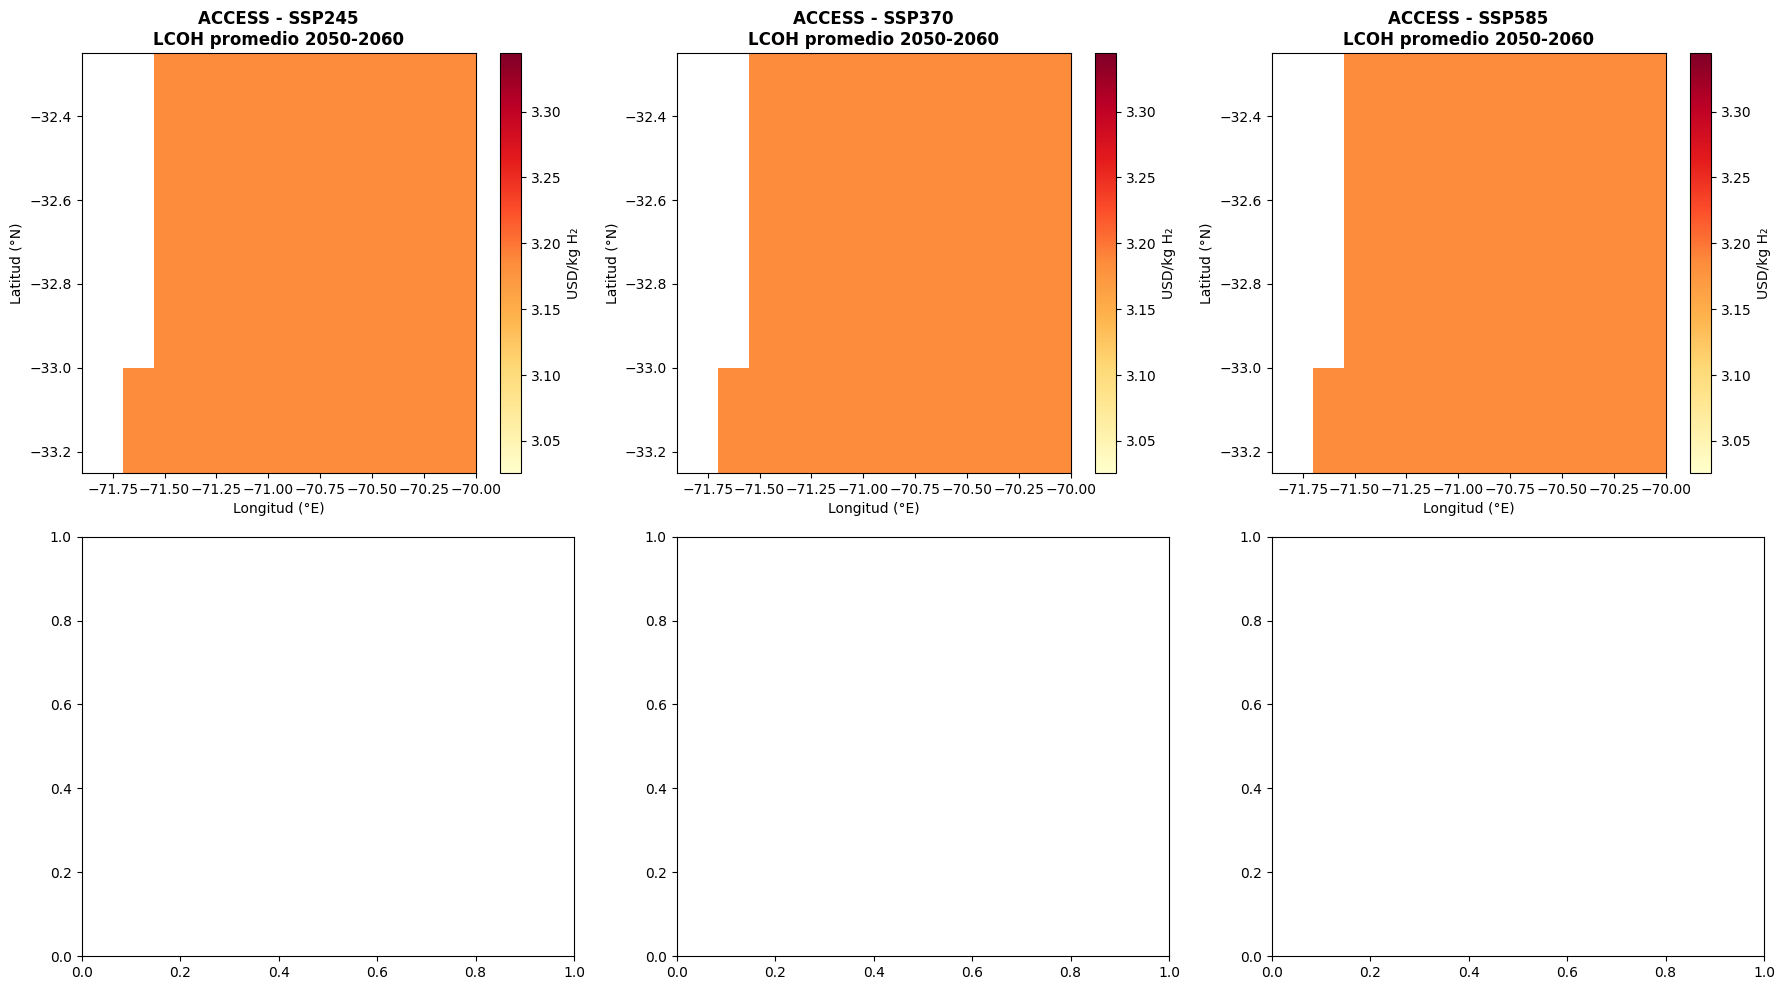

In [10]:
# Visualizar LCOH promedio (2050-2060) para cada escenario
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_idx = 0
for key, ds in results.items():
    if plot_idx >= 6:
        break
    
    model, scenario = key.split('_')
    
    # Seleccionar período 2050-2060
    ds_period = ds.sel(time=slice('2050', '2060'))
    lcoh_mean = ds_period['LCOH_per_kg'].mean(dim='time')
    
    # Plot
    im = lcoh_mean.plot(ax=axes[plot_idx], cmap='YlOrRd', 
                        add_colorbar=True, cbar_kwargs={'label': 'USD/kg H₂'})
    axes[plot_idx].set_title(f'{model.upper()} - {scenario.upper()}\nLCOH promedio 2050-2060', 
                             fontweight='bold')
    axes[plot_idx].set_xlabel('Longitud (°E)')
    axes[plot_idx].set_ylabel('Latitud (°N)')
    
    plot_idx += 1

plt.tight_layout()
plot_file = BASE_DIR / 'reports' / f'h2v_lcoh_maps_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapas guardados: {plot_file.name}")
plt.show()

## 10. Resumen estadístico

In [11]:
# Estadísticas por escenario
summary_rows = []

for key, ds in results.items():
    model, scenario = key.split('_')
    
    # Período 2030
    ds_2030 = ds.sel(time='2030', method='nearest')
    # Período 2050
    ds_2050 = ds.sel(time='2050', method='nearest')
    # Período 2100
    ds_2100 = ds.sel(time='2100', method='nearest')
    
    summary_rows.append({
        'Model': model.upper(),
        'Scenario': scenario.upper(),
        'LCOH_2030_mean_USD_per_kg': float(ds_2030['LCOH_per_kg'].mean().values),
        'LCOH_2050_mean_USD_per_kg': float(ds_2050['LCOH_per_kg'].mean().values),
        'LCOH_2100_mean_USD_per_kg': float(ds_2100['LCOH_per_kg'].mean().values),
        'PV_capacity_2030_MW': float(ds_2030['PV_capacity_MW'].sum().values),
        'PV_capacity_2050_MW': float(ds_2050['PV_capacity_MW'].sum().values),
        'PV_capacity_2100_MW': float(ds_2100['PV_capacity_MW'].sum().values),
        'H2_production_2030_kt': float(ds_2030['H2_production_kg'].sum().values) / 1e6,
        'H2_production_2050_kt': float(ds_2050['H2_production_kg'].sum().values) / 1e6,
        'H2_production_2100_kt': float(ds_2100['H2_production_kg'].sum().values) / 1e6,
    })

df_summary = pd.DataFrame(summary_rows)
summary_file = OUTPUT_DIR / f'h2v_indicators_summary_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
df_summary.to_csv(summary_file, index=False)

print("\n" + "="*70)
print("RESUMEN DE INDICADORES H2V POR ESCENARIO")
print("="*70)
print(df_summary.to_string(index=False))
print(f"\n✅ Resumen guardado: {summary_file.name}")


RESUMEN DE INDICADORES H2V POR ESCENARIO
 Model Scenario  LCOH_2030_mean_USD_per_kg  LCOH_2050_mean_USD_per_kg  LCOH_2100_mean_USD_per_kg  PV_capacity_2030_MW  PV_capacity_2050_MW  PV_capacity_2100_MW  H2_production_2030_kt  H2_production_2050_kt  H2_production_2100_kt
ACCESS   SSP245                   3.185059                   3.185059                   3.185059        461961.966534         2.785630e+06         8.594799e+06           46698.363992          281591.035078          868822.712791
ACCESS   SSP370                   3.185059                   3.185059                   3.185059        461961.966534         2.785630e+06         8.594799e+06           46698.363992          281591.035078          868822.712791
ACCESS   SSP585                   3.185059                   3.185059                   3.185059        461961.966534         2.785630e+06         8.594799e+06           46698.363992          281591.035078          868822.712791

✅ Resumen guardado: h2v_indicators_summar

## 11. Verificación de compatibilidad con indicadores climáticos

In [12]:
# Verificar que las dimensiones coinciden
print("\n" + "="*70)
print("VERIFICACIÓN DE COMPATIBILIDAD ESPACIAL")
print("="*70)

# Cargar un indicador climático de referencia
climate_file = INDICATORS_DIR / 'climate_indicators_ACCESS-CM2_ssp245_2015-2100.nc'
ds_climate = xr.open_dataset(climate_file)

# Comparar con un dataset H2V
ds_h2v = results['access_ssp245']

print(f"\nIndicadores climáticos:")
print(f"  Dimensiones: {ds_climate.dims}")
print(f"  Variables: {len(ds_climate.data_vars)} ({', '.join(list(ds_climate.data_vars)[:5])}...)")

print(f"\nIndicadores H2V:")
print(f"  Dimensiones: {ds_h2v.dims}")
print(f"  Variables: {len(ds_h2v.data_vars)} ({', '.join(list(ds_h2v.data_vars)[:5])}...)")

# Verificar coordenadas
lat_match = np.allclose(ds_climate.lat.values, ds_h2v.lat.values)
lon_match = np.allclose(ds_climate.lon.values, ds_h2v.lon.values)

print(f"\n✓ Latitudes coinciden: {'✅ SÍ' if lat_match else '❌ NO'}")
print(f"✓ Longitudes coinciden: {'✅ SÍ' if lon_match else '❌ NO'}")

if lat_match and lon_match:
    print(f"\n🎉 ¡PERFECTO! Los indicadores H2V son completamente compatibles")
    print(f"   con los indicadores climáticos para el autoencoder.")
    print(f"\n   Total de variables disponibles: {len(ds_climate.data_vars) + len(ds_h2v.data_vars)}")
    print(f"   - {len(ds_climate.data_vars)} indicadores climáticos")
    print(f"   - {len(ds_h2v.data_vars)} indicadores del sistema H2V")

ds_climate.close()


VERIFICACIÓN DE COMPATIBILIDAD ESPACIAL

Indicadores climáticos:
  Dimensiones: FrozenMappingWarningOnValuesAccess({'time': 1118, 'lat': 20, 'lon': 38})
  Variables: 32 (tasmin_mean, tasmin_std, tasmin_min, tasmin_max, tasmin_extreme_days...)

Indicadores H2V:
  Dimensiones: FrozenMappingWarningOnValuesAccess({'time': 78, 'lat': 20, 'lon': 38})
  Variables: 13 (LCOH_per_MWh, LCOH_per_kg, PV_capacity_MW, Electrolyzer_capacity_MW, H2_storage_capacity_MWh...)

✓ Latitudes coinciden: ✅ SÍ
✓ Longitudes coinciden: ✅ SÍ

🎉 ¡PERFECTO! Los indicadores H2V son completamente compatibles
   con los indicadores climáticos para el autoencoder.

   Total de variables disponibles: 45
   - 32 indicadores climáticos
   - 13 indicadores del sistema H2V


## Resumen final

Este notebook ha generado:

1. **Archivos NetCDF** con indicadores espaciotemporales del sistema H2V:
   - 6 archivos (2 modelos × 3 escenarios)
   - 760 puntos espaciales (20 lat × 38 lon)
   - 78 años (2023-2100)
   - 13 indicadores por punto

2. **CSV consolidado** con todos los escenarios en formato largo

3. **Visualizaciones** de mapas de LCOH por escenario

4. **Resumen estadístico** con métricas clave por escenario

Los indicadores generados son:
- `LCOH_per_MWh`, `LCOH_per_kg`: Costo nivelado del hidrógeno
- `PV_capacity_MW`, `Electrolyzer_capacity_MW`: Capacidades instaladas
- `H2_storage_capacity_MWh`: Almacenamiento
- `PV_CF_mean`: Factor de capacidad fotovoltaica
- `H2_production_MWh`, `H2_production_kg`: Producción de hidrógeno
- `Electricity_consumption_MWh`, `Water_consumption_m3`: Consumos
- `Total_cost_annual_USD`, `CAPEX_annual_USD`, `OPEX_annual_USD`: Costos

**Compatibilidad:** ✅ Los indicadores H2V tienen las mismas dimensiones espaciales (lat, lon) que los indicadores climáticos, permitiendo su uso directo en el modelo de aprendizaje profundo (autoencoder).